In [1]:
# Iris · сбалансированная многоклассовая классификация

#Контекст: все 3 класса по 50 образцов
#Целевые метрики: accuracy, macro-F1, ROC AUC (OvR)
#Почему: при балансе классов все метрики согласованы, `accuracy` не обманывает

In [2]:
import json, joblib, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

# ── найти корень проекта (ищет requirements.txt вверх по дереву) ──
def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')

SEED    = 42
PROJECT = find_project_root()
TASK    = 'iris'                                      # ← меняется в каждом nb

MODEL_DIR = PROJECT / 'models' / 'classification' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'classification' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

PROJECT  : /app
MODEL_DIR: /app/models/classification/iris
ART_DIR  : /app/artifacts/classification/iris


In [3]:
def all_metrics(y_true, y_pred, y_proba=None, positive_label=1):
    """
    Считает набор метрик для бинарной и многоклассовой классификации.

    Бинарная задача (2 класса) + y_proba:
        roc_auc, pr_auc, specificity, sensitivity.
    Многоклассовая задача (>2 классов) + y_proba:
        roc_auc_ovr_macro, roc_auc_ovr_weighted, roc_auc_ovo_macro, pr_auc_macro.
    """
    m = {
        'accuracy':          accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_macro':   precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':      recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':          f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'f0.5_macro':        fbeta_score(y_true, y_pred, beta=0.5, average='macro', zero_division=0),
        'f2_macro':          fbeta_score(y_true, y_pred, beta=2.0, average='macro', zero_division=0),
        'mcc':               matthews_corrcoef(y_true, y_pred),
        'kappa':             cohen_kappa_score(y_true, y_pred),
    }

    y_true_arr = np.asarray(y_true)
    n_classes  = len(np.unique(y_true_arr))

    if y_proba is None:
        return m

    if n_classes == 2:
        # ── бинарный случай ──
        p = y_proba[:, positive_label] if y_proba.ndim == 2 else y_proba
        m['roc_auc'] = roc_auc_score(y_true_arr, p)
        m['pr_auc']  = average_precision_score(y_true_arr, p)
        cm = confusion_matrix(y_true_arr, y_pred)
        tn, fp, fn, tp = cm.ravel()
        m['specificity'] = tn / (tn + fp) if (tn + fp) else 0.0
        m['sensitivity'] = tp / (tp + fn) if (tp + fn) else 0.0

    elif n_classes > 2:
        # ── многоклассовый случай (OvR / OvO) ──
        m['roc_auc_ovr_macro']    = roc_auc_score(y_true_arr, y_proba,
                                                  multi_class='ovr', average='macro')
        m['roc_auc_ovr_weighted'] = roc_auc_score(y_true_arr, y_proba,
                                                  multi_class='ovr', average='weighted')
        m['roc_auc_ovo_macro']    = roc_auc_score(y_true_arr, y_proba,
                                                  multi_class='ovo', average='macro')

        # PR-AUC One-vs-Rest, макро-усреднение по классам
        classes = np.unique(y_true_arr)
        y_bin   = label_binarize(y_true_arr, classes=classes)
        ap_per_class = [
            average_precision_score(y_bin[:, i], y_proba[:, i])
            for i in range(len(classes))
        ]
        m['pr_auc_macro'] = float(np.mean(ap_per_class))

    return m


def metrics_table(results: dict) -> pd.DataFrame:
    df = pd.DataFrame(results).T.round(4)
    preferred = [
        'accuracy', 'balanced_accuracy',
        'precision_macro', 'recall_macro', 'f1_macro', 'f1_weighted',
        'f0.5_macro', 'f2_macro',
        'roc_auc', 'roc_auc_ovr_macro', 'roc_auc_ovr_weighted', 'roc_auc_ovo_macro',
        'pr_auc', 'pr_auc_macro',
        'specificity', 'sensitivity',
        'mcc', 'kappa',
    ]
    cols = [c for c in preferred if c in df.columns] + \
           [c for c in df.columns if c not in preferred]
    return df[cols]


def plot_confusion(cm, labels, title, ax=None):
    ax = ax if ax is not None else plt.gca()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)

In [4]:
## 1. Загрузка данных

In [5]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X = iris.data.values
y = iris.target.values
FEATURES = list(iris.feature_names)
CLASSES  = list(iris.target_names)

df = pd.DataFrame(X, columns=FEATURES).assign(target=y, name=[CLASSES[i] for i in y])
print('X:', X.shape, '| classes:', CLASSES)
df.head()

X: (150, 4) | classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [6]:
## 2. EDA — баланс классов

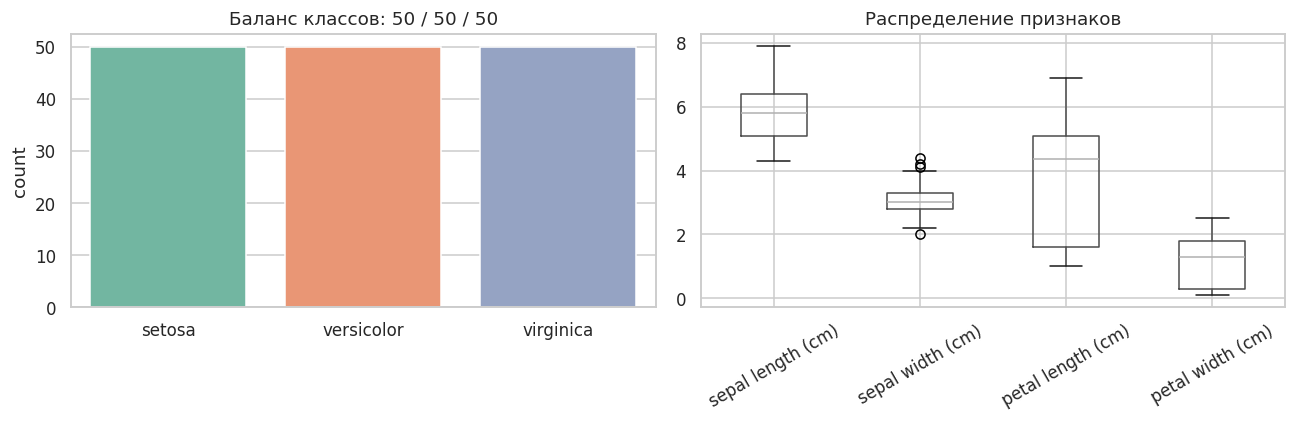

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='name', palette='Set2', ax=axes[0])
axes[0].set_title('Баланс классов: 50 / 50 / 50')
axes[0].set_xlabel('')

df[FEATURES].boxplot(ax=axes[1], rot=30)
axes[1].set_title('Распределение признаков')

plt.tight_layout()
plt.savefig(ART_DIR / 'eda.png', bbox_inches='tight')
plt.show()

In [8]:
## 3. Train / test split (стратифицированный)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)
print('train:', X_train.shape, '| test:', X_test.shape)
print('balance train:', dict(zip(*np.unique(y_train, return_counts=True))))
print('balance test :', dict(zip(*np.unique(y_test,  return_counts=True))))

train: (112, 4) | test: (38, 4)
balance train: {np.int64(0): np.int64(38), np.int64(1): np.int64(37), np.int64(2): np.int64(37)}
balance test : {np.int64(0): np.int64(12), np.int64(1): np.int64(13), np.int64(2): np.int64(13)}


In [10]:
## 4. Модели — обучаем и считаем метрики

In [11]:
models = {
    'LogReg':       Pipeline([('sc', StandardScaler()),
                              ('m', LogisticRegression(max_iter=1000, random_state=SEED))]),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    'GradBoost':    GradientBoostingClassifier(random_state=SEED),
}

results, preds, probas, fitted = {}, {}, {}, {}
for name, m in models.items():
    m.fit(X_train, y_train)
    y_pred  = m.predict(X_test)
    y_proba = m.predict_proba(X_test)
    results[name] = all_metrics(y_test, y_pred, y_proba)
    preds[name], probas[name], fitted[name] = y_pred, y_proba, m

metrics_table(results)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,roc_auc_ovr_macro,roc_auc_ovr_weighted,roc_auc_ovo_macro,pr_auc_macro,mcc,kappa
LogReg,0.9211,0.9231,0.9246,0.9231,0.9230,0.9209,0.9237,0.9228,0.9959,0.9958,0.9961,0.9928,0.8824,0.8815
RandomForest,0.8947,0.8974,0.9030,0.8974,0.8968,0.8941,0.8997,0.8964,0.9887,0.9884,0.9889,0.9828,0.8455,0.8420
GradBoost,0.9737,0.9744,0.9762,0.9744,0.9743,0.9736,0.9752,0.9741,0.9908,0.9905,0.9910,0.9846,0.9615,0.9605


In [12]:
## 5. Confusion matrices

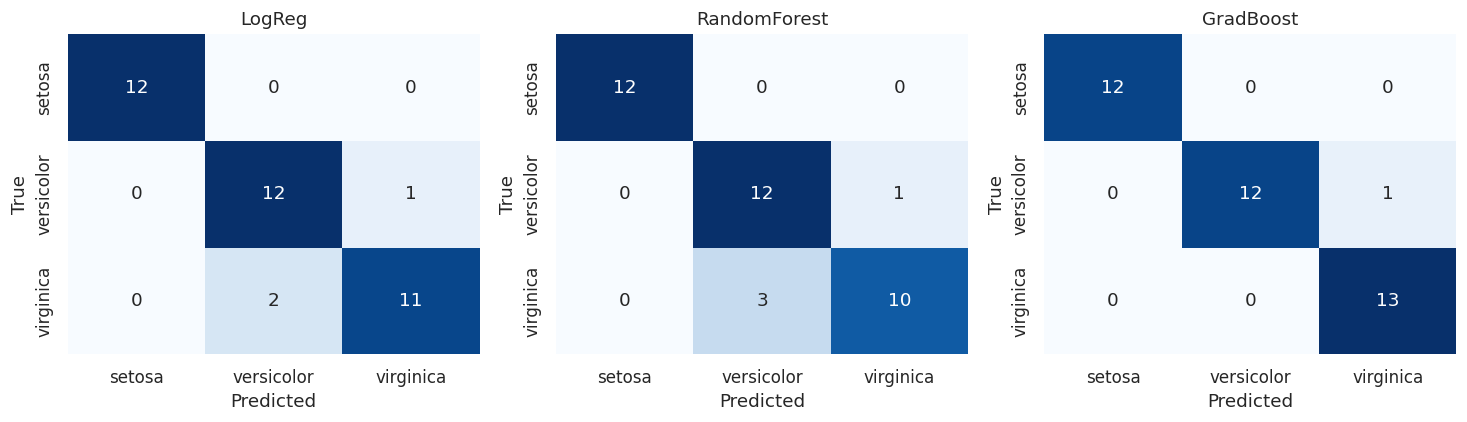

In [13]:
fig, axes = plt.subplots(1, len(models), figsize=(4.5 * len(models), 4))
for ax, name in zip(np.atleast_1d(axes), models.keys()):
    cm = confusion_matrix(y_test, preds[name])
    plot_confusion(cm, CLASSES, name, ax)
plt.tight_layout()
plt.savefig(ART_DIR / 'confusion_matrices.png', bbox_inches='tight')
plt.show()

In [14]:
## 6. ROC-кривые One-vs-Rest

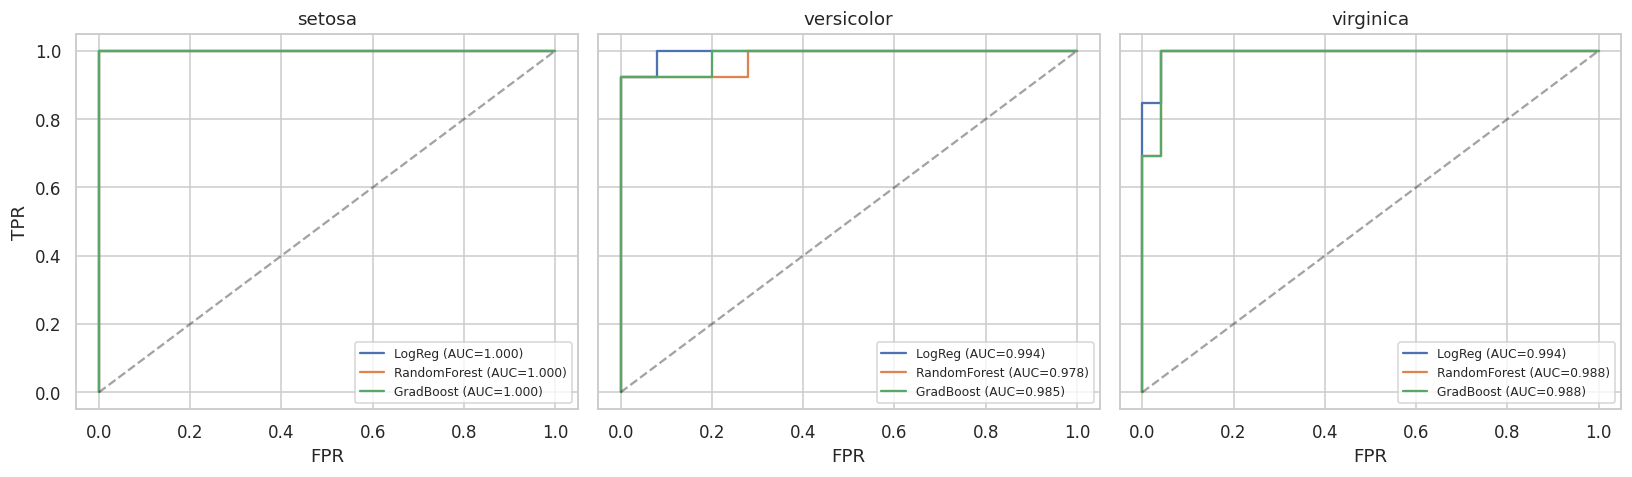

In [15]:
y_bin = label_binarize(y_test, classes=list(range(len(CLASSES))))

fig, axes = plt.subplots(1, len(CLASSES), figsize=(5 * len(CLASSES), 4.5), sharey=True)
for i, cls_name in enumerate(CLASSES):
    ax = axes[i]
    for name, p in probas.items():
        fpr, tpr, _ = roc_curve(y_bin[:, i], p[:, i])
        auc = roc_auc_score(y_bin[:, i], p[:, i])
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_title(cls_name); ax.set_xlabel('FPR')
    if i == 0: ax.set_ylabel('TPR')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(ART_DIR / 'roc_ovr.png', bbox_inches='tight')
plt.show()

In [16]:
## 7. Вывод

# Классы сбалансированы → accuracy и macro-F1 согласованы, обе можно использовать
# ROC AUC OvR близка к 1.0 → модель уверенно разделяет все три класса
# Если бы был только один «лучший по accuracy» — скорее всего это GradBoost или RandomForest
# Выбираем **macro-F1** как основную метрику: она не даёт классам с большим числом образцов перевесить итог

In [17]:
best_name  = max(results, key=lambda n: results[n]['f1_macro'])
best_model = fitted[best_name]
print(f'Лучшая модель: {best_name} · macro-F1 = {results[best_name]["f1_macro"]:.4f}')

stamp = datetime.now().strftime('%Y%m%d_%H%M')
model_path = MODEL_DIR / f'iris_{best_name.lower()}.joblib'
meta_path  = MODEL_DIR / f'iris_{best_name.lower()}_{stamp}.json'

joblib.dump(best_model, model_path)

meta = {
    'task': 'iris_balanced',
    'model': best_name,
    'features': FEATURES,
    'classes': CLASSES,
    'metrics': results[best_name],
    'seed': SEED,
    'saved_at': datetime.now().isoformat(),
    'model_path': str(model_path.relative_to(PROJECT)),
}
meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False))

print('saved model →', model_path)
print('saved meta  →', meta_path)

Лучшая модель: GradBoost · macro-F1 = 0.9743
saved model → /app/models/classification/iris/iris_gradboost.joblib
saved meta  → /app/models/classification/iris/iris_gradboost_20261006_1358.json


In [18]:
## 8. Перезагрузка модели и проверка

In [19]:
loaded = joblib.load(model_path)
y_pred_reload = loaded.predict(X_test)
reload_metrics = all_metrics(y_test, y_pred_reload, loaded.predict_proba(X_test))

diff = {k: abs(reload_metrics[k] - results[best_name][k]) for k in reload_metrics}
assert all(v < 1e-9 for v in diff.values()), f'Расхождение: {diff}'

print('OK: метрики после reload идентичны')
print(pd.Series(reload_metrics).round(4))

OK: метрики после reload идентичны
accuracy                0.9737
balanced_accuracy       0.9744
precision_macro         0.9762
recall_macro            0.9744
f1_macro                0.9743
f1_weighted             0.9736
f0.5_macro              0.9752
f2_macro                0.9741
mcc                     0.9615
kappa                   0.9605
roc_auc_ovr_macro       0.9908
roc_auc_ovr_weighted    0.9905
roc_auc_ovo_macro       0.9910
pr_auc_macro            0.9846
dtype: float64


In [20]:
## 9. Сборка report.json + index.json для test.html

import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ---------- хелперы ----------
def _to_native(obj):
    if isinstance(obj, dict):           return {k: _to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):  return [_to_native(v) for v in obj]
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, pd.Series):      return obj.tolist()
    return obj

def _load_index(path):
    p = Path(path)
    if p.exists():
        return json.loads(p.read_text())
    return {"generated_at": None, "tasks": []}

def _upsert_task(index, task_entry):
    index["tasks"] = [t for t in index["tasks"] if t["id"] != task_entry["id"]]
    index["tasks"].append(task_entry)
    index["tasks"].sort(key=lambda t: t["id"])
    index["generated_at"] = datetime.now().isoformat()
    return index

# ---------- hero-метрика: macro-F1 ----------
HERO_METRIC  = 'f1_macro'
best_name    = max(results, key=lambda n: results[n][HERO_METRIC])
best_pred    = preds[best_name]
best_proba   = probas[best_name]
n_classes    = len(CLASSES)

# ---------- базовые статистики датасета ----------
DATASET_STATS = {
    'n_samples':  int(len(X)),
    'n_features': int(len(FEATURES)),
    'n_classes':  int(n_classes),
    'n_train':    int(len(X_train)),
    'n_test':     int(len(X_test)),
}
TARGET_STATS = {
    'class_distribution': {
        cls: int((y == i).sum()) for i, cls in enumerate(CLASSES)
    },
    'class_distribution_test': {
        cls: int((y_test == i).sum()) for i, cls in enumerate(CLASSES)
    },
    'is_balanced': bool(
        len(set(int((y == i).sum()) for i in range(n_classes))) == 1
    ),
}

# ---------- блок моделей ----------
models_block = []
for name, m in results.items():
    y_pred  = preds[name]
    y_proba = probas[name]

    # per-class: precision / recall / f1 / support
    cls_report = classification_report(
        y_test, y_pred, target_names=CLASSES,
        output_dict=True, zero_division=0,
    )
    per_class = {
        cls: {
            'precision': float(cls_report[cls]['precision']),
            'recall':    float(cls_report[cls]['recall']),
            'f1':        float(cls_report[cls]['f1-score']),
            'support':   int(cls_report[cls]['support']),
        } for cls in CLASSES
    }

    # confusion matrix как nested list
    cm = confusion_matrix(y_test, y_pred, labels=list(range(n_classes))).tolist()

    # ROC AUC One-vs-Rest по классам + макро-усреднение
    roc_auc_per_class = {}
    for i, cls in enumerate(CLASSES):
        y_bin_i = (y_test == i).astype(int)
        roc_auc_per_class[cls] = float(roc_auc_score(y_bin_i, y_proba[:, i]))
    roc_auc_ovr_macro = float(np.mean(list(roc_auc_per_class.values())))

    # уверенность модели
    mean_confidence   = float(np.mean(np.max(y_proba, axis=1)))
    median_confidence = float(np.median(np.max(y_proba, axis=1)))

    entry = {
        'name': name,
        'is_best': name == best_name,
        'metrics': {
            k: float(v) for k, v in m.items()
            if isinstance(v, (int, float, np.integer, np.floating))
        },
        'per_class':          per_class,
        'confusion_matrix':   cm,
        'roc_auc_per_class':  roc_auc_per_class,
        'roc_auc_ovr_macro':  roc_auc_ovr_macro,
        'mean_confidence':    mean_confidence,
        'median_confidence':  median_confidence,
    }

    # feature importance / coef
    if hasattr(m, 'feature_importances_'):
        fi = m.feature_importances_
        entry['feature_importance'] = sorted(
            [{'name': f, 'value': float(v)} for f, v in zip(FEATURES, fi)],
            key=lambda x: x['value'], reverse=True,
        )
    elif hasattr(m, 'named_steps') and 'm' in m.named_steps \
         and hasattr(m.named_steps['m'], 'coef_'):
        coef = m.named_steps['m'].coef_
        entry['feature_importance'] = sorted(
            [{'name': f, 'value': float(np.mean(np.abs(coef[:, i])))}
             for i, f in enumerate(FEATURES)],
            key=lambda x: x['value'], reverse=True,
        )
    models_block.append(entry)

# ---------- by_metric: включая целевые ROC-AUC ----------
metric_keys = [
    'accuracy', 'balanced_accuracy',
    'precision_macro', 'recall_macro',
    'f1_macro', 'f1_weighted', 'f0.5_macro', 'f2_macro',
    'roc_auc_ovr_macro', 'roc_auc_ovr_weighted', 'roc_auc_ovo_macro',
    'pr_auc_macro',
    'mcc', 'kappa',
]
by_metric = {
    k: max(results, key=lambda n: results[n].get(k, -np.inf))
    for k in metric_keys
    if any(k in results[n] for n in results)
}

# ---------- per-class error rate у best-модели ----------
error_by_class = {}
for i, cls in enumerate(CLASSES):
    mask = (y_test == i)
    err  = float(np.mean(best_pred[mask] != i))
    error_by_class[cls] = {
        'support':    int(mask.sum()),
        'error_rate': err,
        'accuracy':   1.0 - err,
    }

# ---------- sample predictions ----------
correct_idx = np.where(best_pred == y_test)[0]
wrong_idx   = np.where(best_pred != y_test)[0]

if len(correct_idx):
    conf_correct = best_proba[correct_idx, best_pred[correct_idx]]
    correct_sorted = correct_idx[np.argsort(-conf_correct)]
else:
    correct_sorted = correct_idx

if len(wrong_idx):
    conf_wrong = best_proba[wrong_idx, best_pred[wrong_idx]]
    wrong_sorted = wrong_idx[np.argsort(conf_wrong)]
else:
    wrong_sorted = wrong_idx

def _make_sample(idx):
    return {
        'features':   {f: float(v) for f, v in zip(FEATURES, X_test[idx])},
        'true':       CLASSES[int(y_test[idx])],
        'predicted':  CLASSES[int(best_pred[idx])],
        'correct':    bool(best_pred[idx] == y_test[idx]),
        'confidence': float(best_proba[idx].max()),
        'proba':      {cls: float(p) for cls, p in zip(CLASSES, best_proba[idx])},
    }

sample_predictions = (
    [_make_sample(int(i)) for i in correct_sorted[:5]] +
    [_make_sample(int(i)) for i in wrong_sorted[:5]]
)

# ---------- headline diagnostics ----------
roc_auc_macro_best = float(results[best_name].get(
    'roc_auc_ovr_macro',
    np.mean(list(next(m for m in models_block
                     if m['name'] == best_name)['roc_auc_per_class'].values()))
))

diag = {
    'is_balanced': bool(TARGET_STATS['is_balanced']),
    'accuracy_vs_balanced_accuracy_gap': float(
        abs(results[best_name]['accuracy'] - results[best_name]['balanced_accuracy'])
    ),
    'accuracy_vs_macro_f1_gap': float(
        abs(results[best_name]['accuracy'] - results[best_name]['f1_macro'])
    ),
    'mcc':               float(results[best_name]['mcc']),
    'kappa':             float(results[best_name]['kappa']),
    'roc_auc_ovr_macro': roc_auc_macro_best,
    'mean_confidence':   float(np.mean(np.max(best_proba, axis=1))),
    'per_class_accuracy': {c: v['accuracy'] for c, v in error_by_class.items()},
    'n_errors_on_test':  int(len(wrong_idx)),
    'metrics_are_consistent': bool(
        abs(results[best_name]['accuracy'] - results[best_name]['f1_macro']) < 0.05
    ),
}

# ---------- charts ----------
charts = {}
for candidate in ['eda.png', 'confusion_matrices.png', 'roc_ovr.png']:
    if (ART_DIR / candidate).exists():
        charts[candidate.replace('.png', '')] = candidate

# ---------- report ----------
report = {
    'meta': {
        'task': 'iris_balanced',
        'title': 'Iris · Balanced Multi-class',
        'subtitle': 'При балансе классов accuracy = macro-F1 — метрики согласованы',
        'dataset': 'sklearn.datasets.load_iris',
        'target': 'species',
        'target_unit': '',
        'target_format': 'category',
        'classes': CLASSES,
        'features': FEATURES,
        'seed': SEED,
        'generated_at': datetime.now().isoformat(),
        **DATASET_STATS,
        'target_stats': TARGET_STATS,
        'narrative': {
            'context': (
                'Ирисы Фишера: 150 образцов, 3 класса по 50 штук. Признаки — '
                'длина/ширина чашелистика и лепестка. Классы сбалансированы, поэтому '
                'accuracy, balanced accuracy, macro-F1 и weighted-F1 совпадают: нет '
                'класса-«любимчика», за счёт которого можно накрутить точность.'
            ),
            'hero_metric': 'macro-F1',
            'main_conclusion': (
                f'Лучшая модель — {best_name}: macro-F1 = {results[best_name]["f1_macro"]:.4f}, '
                f'accuracy = {results[best_name]["accuracy"]:.4f}, '
                f'ROC AUC OvR (macro) = {roc_auc_macro_best:.4f}, '
                f'MCC = {results[best_name]["mcc"]:.4f}. '
                'Точности по классам различаются мало (см. per_class_accuracy), '
                'ROC AUC OvR близка к 1.0 — классы хорошо разделимы как по argmax, '
                'так и по вероятностям. При таком балансе accuracy — честная метрика, '
                'дополнительная робастность через macro-F1 нужна для симметрии с '
                'несбалансированными задачами.'
            ),
            'rules': {
                'balance_ok':      'accuracy ≈ macro-F1 (|Δ| < 0.05) → данные сбалансированы',
                'mcc_close_to_1':  'MCC и kappa > 0.9 → модель сильно лучше случайного угадывания',
                'roc_auc_near_1':  'ROC AUC OvR > 0.98 → классы хорошо разделимы',
            },
        },
    },
    'headline': {
        'best_model':       best_name,
        'best_metric':      HERO_METRIC,
        'best_metric_value': float(results[best_name][HERO_METRIC]),
        'verdict': (
            f'Лучшая по macro-F1 = {best_name} '
            f'({results[best_name]["f1_macro"]:.4f} · '
            f'accuracy {results[best_name]["accuracy"]:.4f} · '
            f'ROC AUC OvR {roc_auc_macro_best:.4f} · '
            f'MCC {results[best_name]["mcc"]:.4f})'
        ),
        'diagnostic_verdict': diag,
    },
    'models':             models_block,
    'by_metric':          by_metric,
    'error_by_class':     error_by_class,
    'sample_predictions': sample_predictions,
    'charts':             charts,
    'artifacts': {
        'model_joblib': str(model_path.relative_to(PROJECT)),
        'model_meta':   str(meta_path.relative_to(PROJECT)),
    },
}

report_path = ART_DIR / 'report.json'
report_path.write_text(json.dumps(_to_native(report), indent=2, ensure_ascii=False))

# ---------- index.json ----------
index_path = PROJECT / 'artifacts' / 'index.json'
index = _load_index(index_path)
index = _upsert_task(index, {
    'id':          'iris_balanced',
    'title':       'Iris · Balanced Multi-class',
    'best_model':  best_name,
    'hero_metric': 'macro_f1',
    'hero_value':  float(results[best_name]['f1_macro']),
    'unit':        '',
    'report':      str(report_path.relative_to(PROJECT)),
    'charts_dir':  str(ART_DIR.relative_to(PROJECT)),
})
index_path.write_text(json.dumps(index, indent=2, ensure_ascii=False))

print('report  →', report_path)
print('index   →', index_path)
print('models  :', [m['name'] for m in models_block])
print('best    :', best_name, f'macro-F1 = {results[best_name]["f1_macro"]:.4f}')
print('by_metric winners:')
for k, v in by_metric.items():
    print(f'  {k:22s} → {v}')
print('charts  :', list(charts.keys()))
print('samples :', len(sample_predictions),
      f'(correct: {min(5, len(correct_idx))} / wrong: {min(5, len(wrong_idx))})')
print('diag    :',
      f"balanced={diag['is_balanced']}",
      f"consist={diag['metrics_are_consistent']}",
      f"roc_auc_ovr_macro={diag['roc_auc_ovr_macro']:.4f}")

report  → /app/artifacts/classification/iris/report.json
index   → /app/artifacts/index.json
models  : ['LogReg', 'RandomForest', 'GradBoost']
best    : GradBoost macro-F1 = 0.9743
by_metric winners:
  accuracy               → GradBoost
  balanced_accuracy      → GradBoost
  precision_macro        → GradBoost
  recall_macro           → GradBoost
  f1_macro               → GradBoost
  f1_weighted            → GradBoost
  f0.5_macro             → GradBoost
  f2_macro               → GradBoost
  roc_auc_ovr_macro      → LogReg
  roc_auc_ovr_weighted   → LogReg
  roc_auc_ovo_macro      → LogReg
  pr_auc_macro           → LogReg
  mcc                    → GradBoost
  kappa                  → GradBoost
charts  : ['eda', 'confusion_matrices', 'roc_ovr']
samples : 6 (correct: 5 / wrong: 1)
diag    : balanced=True consist=True roc_auc_ovr_macro=0.9908
